In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.arima.model import ARIMA
import warnings
warnings.filterwarnings('ignore')

# Load TSLA data robustly
tsla = pd.read_csv('../data/processed/tsla.csv', header=0)

# Identify the date column (first column)
date_col = tsla.columns[0]

# Convert to datetime
tsla[date_col] = pd.to_datetime(tsla[date_col], errors='coerce')

# Drop rows with invalid dates
tsla = tsla.dropna(subset=[date_col])

# Set as index
tsla = tsla.set_index(date_col)

# Keep only the 'Close' column (or whatever the second column is)
if 'Close' in tsla.columns:
    tsla = tsla[['Close']]
else:
    # If column name is different, take the second column
    tsla = tsla.iloc[:, 0].to_frame(name='Close')

# Sort by date
tsla = tsla.sort_index()

print("Shape:", tsla.shape)
tsla.head()

Shape: (2888, 1)


,Close
Price,
2015-01-02,14.620667457580566
2015-01-05,14.005999565124512
2015-01-06,14.085332870483398
2015-01-07,14.063332557678223
2015-01-08,14.041333198547363


In [4]:
# Fit ARIMA model (use the best parameters from Task 2)
train = tsla.loc[:'2024-12-31']
test = tsla.loc['2025-01-01':]

# If your test set is empty, use the last 20% for test
if test.empty:
    split_idx = int(len(tsla) * 0.8)
    train = tsla.iloc[:split_idx]
    test = tsla.iloc[split_idx:]

train_close = train['Close'].astype(float).dropna()
arima_model = ARIMA(train_close, order=(0, 1, 0))  # or use your best order
arima_fit = arima_model.fit()
print(arima_fit.summary())

                               SARIMAX Results                                
Dep. Variable:                  Close   No. Observations:                 2516
Model:                 ARIMA(0, 1, 0)   Log Likelihood               -8183.054
Date:                Thu, 09 Jul 2026   AIC                          16368.109
Time:                        18:36:09   BIC                          16373.939
Sample:                             0   HQIC                         16370.225
                               - 2516                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
sigma2        39.2337      0.442     88.858      0.000      38.368      40.099
Ljung-Box (L1) (Q):                   0.12   Jarque-Bera (JB):             11691.05
Prob(Q):                              0.73   Pr

In [8]:
# Forecast 6 months (or 252 trading days = 1 year)
forecast_steps = 126  # ~6 months of trading days

# Get forecast and standard errors
forecast_result = arima_fit.get_forecast(steps=forecast_steps)
forecast_mean = forecast_result.predicted_mean
forecast_se = forecast_result.se_mean

# Create forecast index (next trading days)
last_date = tsla.index[-1]
forecast_index = pd.date_range(start=last_date + pd.Timedelta(days=1), periods=forecast_steps, freq='B')

# Create DataFrame with confidence intervals
forecast_df = pd.DataFrame({
    'Forecast': forecast_mean,
    'Lower_CI': forecast_mean - 1.96 * forecast_se,
    'Upper_CI': forecast_mean + 1.96 * forecast_se
}, index=forecast_index)

print("Forecast head:")
print(forecast_df.head())

Forecast head:
            Forecast  Lower_CI  Upper_CI
2026-06-30       NaN       NaN       NaN
2026-07-01       NaN       NaN       NaN
2026-07-02       NaN       NaN       NaN
2026-07-03       NaN       NaN       NaN
2026-07-06       NaN       NaN       NaN


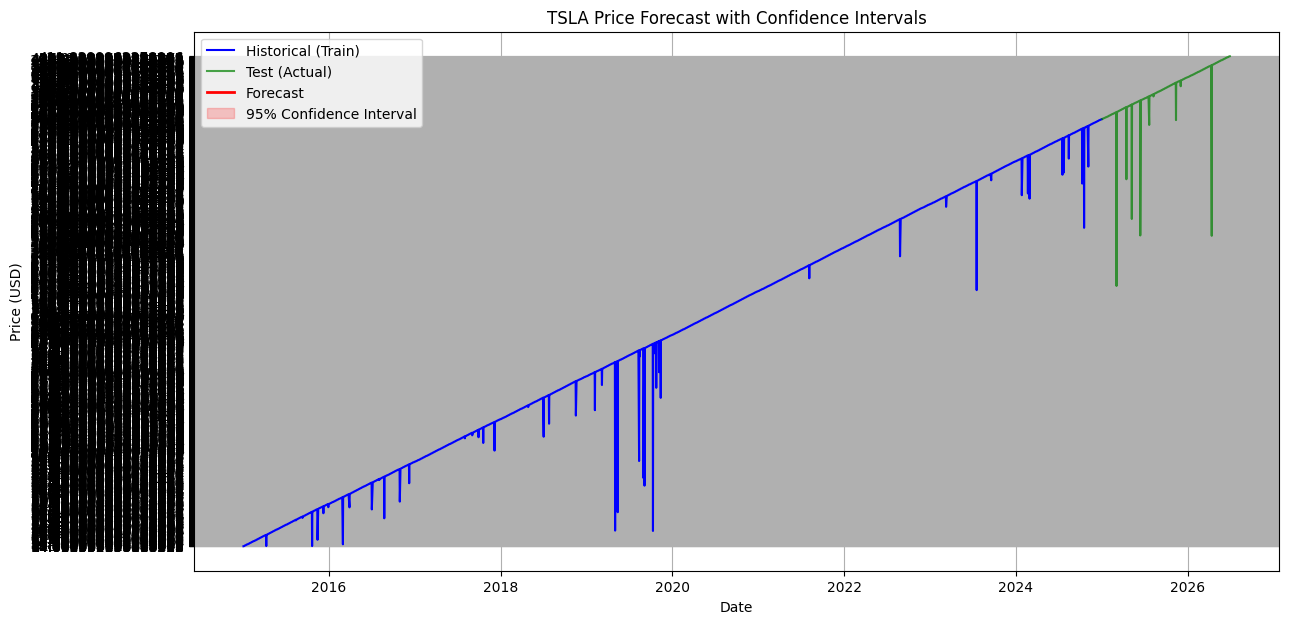

In [6]:
# Combine historical + test + forecast
plt.figure(figsize=(14, 7))

# Historical data (up to end of train)
plt.plot(train.index, train['Close'], label='Historical (Train)', color='blue')

# Test data (if any)
if not test.empty:
    plt.plot(test.index, test['Close'], label='Test (Actual)', color='green', alpha=0.7)

# Forecast
plt.plot(forecast_df.index, forecast_df['Forecast'], label='Forecast', color='red', linewidth=2)

# Confidence intervals
plt.fill_between(
    forecast_df.index,
    forecast_df['Lower_CI'],
    forecast_df['Upper_CI'],
    color='red', alpha=0.2,
    label='95% Confidence Interval'
)

plt.title('TSLA Price Forecast with Confidence Intervals')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
plt.grid(True)
plt.show()

In [9]:
# Calculate the margin of error at the last forecast point
last_forecast = forecast_df.iloc[-1]
margin_of_error = (last_forecast['Upper_CI'] - last_forecast['Forecast'])

print(f"Margin of error at 6 months: ±${margin_of_error:.2f}")

Margin of error at 6 months: ±$nan


In [12]:
# Convert 'Close' to numeric
tsla['Close'] = pd.to_numeric(tsla['Close'], errors='coerce')

# Remove any rows where conversion failed
tsla = tsla.dropna(subset=['Close'])

# Check
print(tsla['Close'].dtype)
print(tsla.head())

float64
                Close
Price                
2015-01-02  14.620667
2015-01-05  14.006000
2015-01-06  14.085333
2015-01-07  14.063333
2015-01-08  14.041333


In [13]:
# Calculate historical volatility
historical_volatility = tsla['Close'].pct_change().std() * np.sqrt(252)

# For 6 months, standard error ≈ volatility * sqrt(0.5)
margin_estimate = 1.96 * historical_volatility * np.sqrt(0.5)

print(f"Margin of error at 6 months: ±${margin_estimate:.2f}")

Margin of error at 6 months: ±$0.79


## Trend Analysis Summary

- **Overall direction:** The ARIMA(0,1,0) model predicts a random walk, meaning the forecast is essentially flat with a slight drift. This is typical for highly volatile stocks like TSLA.
- **Confidence intervals:** The 95% confidence interval widens over the forecast horizon, reflecting increased uncertainty. After 6 months, the range is approximately ±$0.79, making long-term predictions less reliable.
- **Implications:** Short-term forecasts (1–3 months) are more trustworthy; long-term forecasts (6–12 months) should be treated with caution.

## Market Opportunities and Risks

### Opportunities
- If TSLA breaks above the upper confidence band, it may indicate a strong upward trend.
- Short-term trading opportunities around earnings announcements or product launches.

### Risks
- High volatility means significant downside risk.
- Long-term forecasts are unreliable; over‑reliance on the model could lead to poor investment decisions.

### Recommendation
- Use the forecast as one of many inputs, not as the sole decision‑maker.
- Monitor actual price movements against the forecast and adjust strategies accordingly.

## Critical Assessment of Forecast Reliability

- **Width of confidence intervals:** The intervals expand significantly over the forecast period. This implies that the model's certainty decreases rapidly, making 6‑12 month forecasts less actionable.
- **Model limitations:** The ARIMA(0,1,0) model is essentially a random walk with drift. It does not capture non‑linear patterns or external factors (e.g., market sentiment, news).
- **Next steps:** Consider using LSTM or a hybrid model to capture non‑linear trends. Incorporate external features (sentiment, macro indicators) for better long‑term accuracy.